In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import os 
import glob

In [2]:
adata = sc.read_h5ad('/data1st1/junyi/correctdata/GSE133549/all.h5ad')

In [3]:
adata.obs

,source_file,sample_id
10X2x5K_64220_AAACCTGAGACGCACA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGAGCCACCTG,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGAGTGCGTGA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGCACTGTGTA,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
10X2x5K_64220_AAACCTGCAGACTCGC,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...,GSE133535_10X2x5Kcell250Kreads_human_exp_mat.t...
...,...,...
1CB_S1_TTTGTGTCCTATAGAG,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCCTTCAGGT,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCGCTTCAAT,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz
1CB_S1_TTTGTGTCTCCAGTCC,GSE133548_inDrop_human_exp_mat.tsv.gz,GSE133548_inDrop_human_exp_mat.tsv.gz


In [ ]:
adata.obs 

In [ ]:
adata.obs['sample_id'].value_counts()

In [ ]:
# ==== 把 CellBench_metadata 里的全部 metadata 导入 pandas（GSE118767 的 ground truth 标签）====
meta_dir = "/data1st1/junyi/correctdata/GSE118767/CellBench_metadata/"

# 1) 读入全部 14 个 metadata 文件，行名 = 细胞/孔位，加 dataset 列标注来源
meta_files = sorted(glob.glob(os.path.join(meta_dir, "*.metadata.csv.gz")))
print(f"找到 {len(meta_files)} 个 metadata 文件")

frames = []
for fp in meta_files:
    dataset = os.path.basename(fp).replace(".metadata.csv.gz", "")
    df = pd.read_csv(fp, index_col=0)
    df.index.name = "cell"
    df["dataset"] = dataset
    frames.append(df)
meta_all = pd.concat(frames)
print("合并后形状:", meta_all.shape)

# 2) 修正 CellBench 的数据 bug：5cl 板的 p2/p3 行名被误标成 p1_ 前缀 -> 统一剥掉 p1_
mask5cl = meta_all["dataset"].str.startswith("sc_celseq2_5cl")
meta_all.index = [i[3:] if (m and i.startswith("p1_")) else i
                  for m, i in zip(mask5cl, meta_all.index)]

# 3) 只保留标签列（去掉 unaligned/mapped_* 等纯 QC 统计列），方便使用
LABEL_COLS = ["H1975", "H2228", "HCC827", "traj", "poor_quality",          # cellmix: 每孔各细胞系细胞数
              "H2228_prop", "H1975_prop", "HCC827_prop", "mRNA_amount", "mix",  # RNAmix: RNA 混合比例
              "cell_line", "cell_line_demuxlet", "demuxlet_cls"]           # 单细胞: 每细胞细胞系身份
labels = meta_all[LABEL_COLS + ["dataset"]].copy()
print()
print("=== 每个数据集的标签覆盖（非空行数）===")
print(labels.groupby("dataset")[LABEL_COLS].apply(lambda s: s.notna().sum()).to_string())
print()
print("=== 抽查 ===")
labels[labels["dataset"] == "cellmix1"].head(3)

In [ ]:
labels.drop_duplicates(subset=["dataset"])

In [ ]:
adata

In [ ]:
adata_subset = adata[adata.obs["sample_id"].isin(["GSE133536_10X8x10Kcell25Kreads_human_exp_mat.tsv.gz", 
                                                  "GSE133535_10X2x5Kcell250Kreads_human_exp_mat.tsv.gz", 
                                                  "GSE133540_Dropseq_human_exp_mat.tsv.gz", 
                                                  "GSE133546_SingleNuclei_human_exp_mat.tsv.gz"])].copy()

In [ ]:
adata_subset.obs[]

In [ ]:
adata_subset.obs['platform'] = adata_subset.obs['sample_id'].str.split('_', expand=True)[1]

In [ ]:
adata_subset.layers['counts'] = adata_subset.X.copy()

In [ ]:
sc.pp.filter_cells(adata_subset, min_genes=100)
sc.pp.filter_genes(adata_subset, min_cells=3)


In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_subset)
# Logarithmize the data
sc.pp.log1p(adata_subset)


In [ ]:
sc.pp.highly_variable_genes(adata_subset, n_top_genes=2000, batch_key="platform")


In [ ]:
sc.pl.highly_variable_genes(adata_subset)


In [ ]:
sc.tl.pca(adata_subset)


In [ ]:
sc.pp.neighbors(adata_subset)
sc.tl.umap(adata_subset)
sc.pl.umap(
    adata_subset,
    color="platform",
    # Setting a smaller point size to get prevent overlap
    size=2,
)


In [ ]:
adata_subset.obs['company']=adata_subset.obs['platform']
adata_subset.write_h5ad('/data1st1/junyi/correctdata/GSE133549/adata_subset.h5ad')

In [2]:
adata_corrected = sc.read_h5ad('/data3/junyi/GSE133549_scvi/adata_subset_scVI.h5ad')

In [ ]:
# ==== 读取 4 个样本 (GSE133535/536/540/546) 的 human metadata 并贴回 adata_subset ====
meta_base = "/data1st1/junyi/correctdata/GSE133549/"
meta_files = [
    "GSE133536/GSE133536_10X8x10Kcell25Kreads_human_metada.tsv.gz",
    "GSE133535/GSE133535_10X2x5Kcell250Kreads_human_metada.tsv.gz",
    "GSE133540/GSE133540_Dropseq_human_metada.tsv.gz",
    "GSE133546/GSE133546_SingleNuclei_human_metada.tsv.gz",
]

# 1) 逐个读取，行名 = 细胞条形码，加 sample 列
frames = []
for fp in meta_files:
    df = pd.read_csv(os.path.join(meta_base, fp), sep='\t', index_col=0, compression='gzip')
    df["sample"] = fp.split("/")[0]
    frames.append(df)
meta = pd.concat(frames)
print("合并后形状:", meta.shape)
print(meta.groupby("sample").size())
print()
print("Species 取值分布:", meta["Species"].value_counts().to_dict())

合并后形状: (102000, 29)
sample
GSE133535    10000
GSE133536    80000
GSE133540     6000
GSE133546     6000
dtype: int64

Species 取值分布: {'Human': 54673, 'Mouse': 41746, 'Doublet': 4087, 'Dog': 1494}


NameError: name 'adata_subset' is not defined

In [9]:
adata_corrected

AnnData object with n_obs × n_vars = 97616 × 38734
    obs: 'source_file', 'sample_id', 'platform', 'n_genes', 'company', 'n_genes_on', '_scvi_batch', '_scvi_labels', 'batch_idx'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'log1p', 'neighbors', 'pca', 'platform_colors', 'umap'
    obsm: 'X_pca', 'X_scVI', 'X_umap', '_scvi_extra_continuous_covs'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: 'counts', 'scvi_nrom_counts', 'scvi_reconstructed_counts', None (.X)

In [10]:
df_obs = pd.merge(adata_corrected.obs, meta, left_index=True, right_index=True, how='left', suffixes=('', '_meta'))

In [12]:
adata_corrected.obs = df_obs

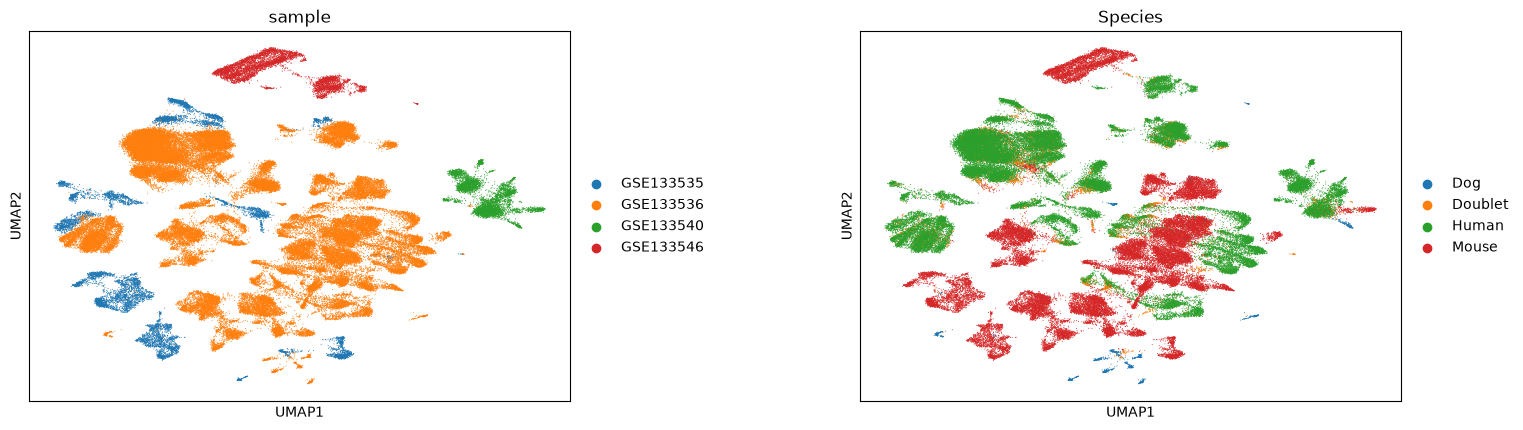

In [15]:
sc.pl.umap(adata_corrected, color=['sample', 'Species'], size=2, wspace=0.4, ncols=2)